## Goals

Here, we re-introduce the latent binwise assignment of compartments A or B from the eigenvector track.

First, we will try to do a simple post-hoc simulation of the $\hat{y}$ values estimated from the previous notebook. There, no latent state was assigned each bin, but only a mixture weight, $w$, of the two compartment distribitutions. 

In [1]:
import arviz as az
import cloudpickle as cp

name = "N_N_HN"

trace = az.from_netcdf(f"../results/traces/{name}_trace.nc")

with open(f"../results/models/{name}_model.pkl", "rb") as f:
    model = cp.load(f)

In [2]:
trace


Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [3]:
model

## Post-hoc decoding of mixture weight

In [4]:
import numpy as np

# Extract posterior samples of w
w_samples = trace.posterior["w"].values   # shape (chains, draws, pos)
w_flat = w_samples.reshape(-1, w_samples.shape[-1])

# Sample z draws
rng = np.random.default_rng()
z_samples = rng.binomial(1, w_flat)   # shape (samples, pos)

# Compute posterior probability of z=1
z_probs = z_samples.mean(axis=0)      # per-position probability


In [5]:
z_probs

array([0.393     , 0.31385714, 0.27742857, ..., 0.05357143, 0.05442857,
       0.05885714], shape=(1460,))

In [6]:
z_samples

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(7000, 1460))

Try some other logic:

In [7]:
threshold = 0.5
# w_samples: shape (n_draws, n_positions)

# How many of the samples are above the threshold?
above_thresh = z_samples < threshold  # shape (samples, n_positions)

# Proportion of Trues in each row:
n_above = above_thresh.sum(axis=0)  # shape: (n_positions,)
# Proportion of samples above threshold for each position
transition_prop = n_above / above_thresh.shape[0]  # shape: (n_positions,)
transition_prop



array([0.607     , 0.68614286, 0.72257143, ..., 0.94642857, 0.94557143,
       0.94114286], shape=(1460,))

In [8]:
lower_bound = 0.05
upper_bound = 0.95

in_transition = (transition_prop > lower_bound) & (transition_prop < upper_bound)

pos = trace.observed_data.pos.values
# Get positions where transition_prop is in the specified range
idx_in_transition = pos[in_transition]
# transition_positions


### Load the data and plot

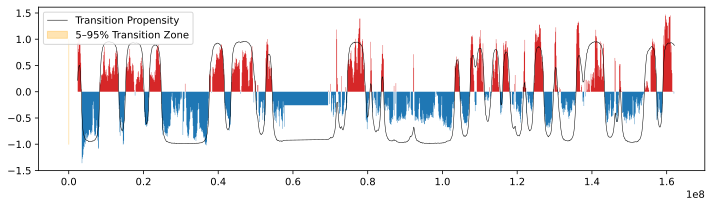

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')


# Load the data
resolution = 100000

y = pd.Series(pd.read_csv(f"../data/eigs/fibroblast.eigs.{resolution}.cis.vecs.tsv", sep="\t")['E1'].values.flatten())
x = pd.Series(np.arange(0,y.shape[0])*resolution)

# Make a DataFrame object
df = pd.DataFrame({"start": x, "e1": y})
df.dropna(inplace=True)

# Plot the data

fig, ax = plt.subplots(figsize=(10, 3))
ax.fill_between(df.start, df.e1, where=df.e1 > 0, color='tab:red', ec='None', step='pre')
ax.fill_between(df.start, df.e1, where=df.e1 < 0, color='tab:blue', ec='None',step='pre') 
ax.plot(df.start, transition_prop/0.5-1, color='black', lw=0.5, label='Transition Propensity')


 #Shade the credible interval
plt.fill_between(
    idx_in_transition,
    -1,
    1,
    color='orange',
    alpha=0.3,
    label=f'{int(lower_bound*100)}–{int(upper_bound*100)}% Transition Zone'
)

plt.legend(loc="upper left")
plt.tight_layout()

## Include z as s rv in the model

Let's fetch the results from the stats of the previous notebook. Then, we will use some of the configs that 1) did not have any divergences or other warnings, and 2) otherwise had good results. 

In [10]:
import pandas as  pd
import arviz as az

model_comparison = pd.read_csv("../results/model_comparison.csv", index_col=0)
valid = model_comparison.query("warning == False")

top3 = model_comparison[:3]
configs = pd.concat([top3, valid])
configs

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
N_T_HT_5_10,0,-358.452110,62.930324,0.000000,4.765703e-01,26.860618,0.000000,True,log
N_N_HT_10,1,-359.459620,65.393423,1.007510,2.252832e-01,26.771997,3.069303,True,log
N_T_HT_10_5,2,-361.000076,66.023840,2.547967,2.724386e-08,26.918152,3.289561,True,log
T_T_HN_10_10,18,-484.641065,45.381785,126.188955,1.850862e-08,27.387257,6.016426,False,log
T_N_HN_10,20,-498.162518,43.544155,139.710408,1.722162e-08,27.387247,6.285019,False,log
T_T_HN_5_10,21,-503.006963,44.417449,144.554853,2.125441e-08,27.781687,7.448034,False,log
T_N_HN_5,22,-516.300853,42.496101,157.848743,2.001360e-08,27.763489,7.684781,False,log
N_T_HN_5,23,-530.303872,43.506794,171.851762,1.092973e-08,27.132629,6.870209,False,log
T_T_HN_10_5,24,-539.210197,42.654365,180.758088,1.413144e-08,27.420135,7.628495,False,log
T_T_HN_5_5,25,-556.981749,41.920557,198.529639,1.692740e-08,27.799341,8.819701,False,log


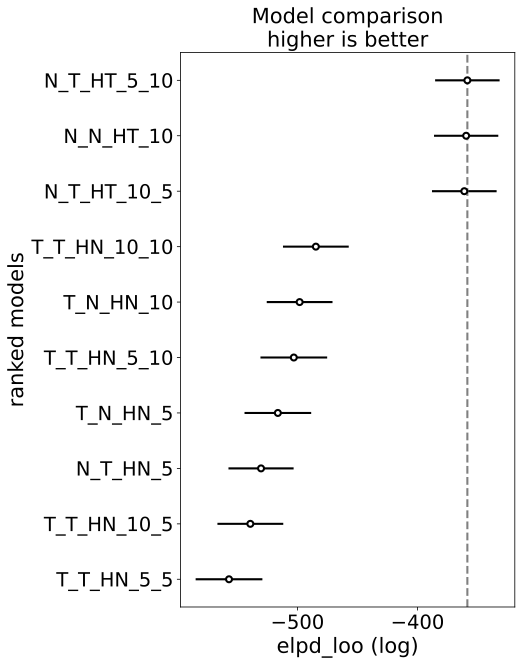

In [11]:
az.plot_compare(configs, order_by_rank=False);

Make a model that includes the latent state $z$ as a stochastic random variable (rv) in the model on a couple of these configs.


In [12]:
top_n = configs[:6].copy()
top_n.index.to_list()

['N_T_HT_5_10',
 'N_N_HT_10',
 'N_T_HT_10_5',
 'T_T_HN_10_10',
 'T_N_HN_10',
 'T_T_HN_5_10']

In [13]:
import json

# Fetch the configs from JSON

with open("../results/model_grid.json", "r") as f:
    model_grid = json.load(f)

In [14]:

# Extract the configs for the top 3 models
configs = [config 
                 for config in model_grid 
                 if config['name'] in top_n.index]
configs


[{'name': 'N_N_HT_10',
  'comp_dist': 'Normal',
  'comp_kwargs': {},
  'eps_dist': 'Normal',
  'eps_kwargs': {'mu': 0.0, 'sigma': 1.0},
  'grw_sigma_dist': 'HalfStudentT',
  'grw_sigma_kwargs': {'nu': 10, 'sigma': 0.05},
  'mu_mu': [-0.5, 0.5],
  'mu_sigma': 0.3,
  'sigma': 0.3},
 {'name': 'N_T_HT_10_5',
  'comp_dist': 'Normal',
  'comp_kwargs': {},
  'eps_dist': 'StudentT',
  'eps_kwargs': {'nu': 10, 'mu': 0.0, 'sigma': 1.0},
  'grw_sigma_dist': 'HalfStudentT',
  'grw_sigma_kwargs': {'nu': 5, 'sigma': 0.01},
  'mu_mu': [-0.5, 0.5],
  'mu_sigma': 0.3,
  'sigma': 0.3},
 {'name': 'N_T_HT_5_10',
  'comp_dist': 'Normal',
  'comp_kwargs': {},
  'eps_dist': 'StudentT',
  'eps_kwargs': {'nu': 5, 'mu': 0.0, 'sigma': 0.5},
  'grw_sigma_dist': 'HalfStudentT',
  'grw_sigma_kwargs': {'nu': 10, 'sigma': 0.05},
  'mu_mu': [-0.5, 0.5],
  'mu_sigma': 0.3,
  'sigma': 0.3},
 {'name': 'T_N_HN_10',
  'comp_dist': 'StudentT',
  'comp_kwargs': {'nu': 10},
  'eps_dist': 'Normal',
  'eps_kwargs': {'mu': 0.0, 

### Model builder

In [15]:
import pymc as pm 
import pytensor.tensor as pt

def build_z_model_from_config(df, cfg):
    """
    Build a PyMC model based on the provided configuration dictionary.
    """

    with pm.Model(coords={"pos": df.index.values}) as model:
        e1 = pm.Data("e1", df.e1.values, dims="pos")

        mu = pm.Normal("mu", mu=cfg['mu_mu'], sigma=cfg['mu_sigma'],
                       transform=pm.distributions.transforms.ordered, shape=2)
        sigma = pm.HalfNormal("sigma", sigma=cfg['sigma'], shape=2)

        # components: Normal or StudentT
        if cfg['comp_dist'] == "Normal":
            components = pm.Normal.dist(mu=mu, sigma=sigma, shape=2)
        else:
            components = pm.StudentT.dist(mu=mu, sigma=sigma, **cfg['comp_kwargs'], shape=2)

        # grw_sigma: HalfNormal or HalfStudentT
        if cfg['grw_sigma_dist'] == "HalfNormal":
            grw_sigma = pm.HalfNormal("grw_sigma", **cfg['grw_sigma_kwargs'])
        else:
            grw_sigma = pm.HalfStudentT("grw_sigma", **cfg['grw_sigma_kwargs'])

        # eps: Normal or StudentT
        if cfg['eps_dist'] == "Normal":
            eps = pm.Normal("eps", dims="pos", **cfg['eps_kwargs'])
        else:
            eps = pm.StudentT("eps", dims="pos", **cfg['eps_kwargs'])

        logit_w = pm.Deterministic("logit_w", pt.cumsum(eps * grw_sigma), dims="pos")
        w = pm.Deterministic("w", pm.math.sigmoid(logit_w), dims="pos")

        # Make a latent variable for the mixture model
        z = pm.Bernoulli("z", p=w, dims="pos")


        y_hat = pm.Mixture("y_hat", w=pt.stack([z, 1-z], axis=1), comp_dists=components,
                           observed=e1, dims='pos')

    return model

### Model sampler

In [16]:
from datetime import datetime

def log(msg, path=".05_PyMC_bernoulli_z.log", overwrite=False):
    print(f"LOG: {msg}")
    if overwrite:
        with open(path, "w") as f:
            f.write(msg + "\n")
    else:
        with open(path, "a") as f:
            f.write(msg + "\n")


# Reset the log file
log("Resetting log... \n", overwrite=True)

model_traces = {}


for i, cfg in enumerate(configs):
    name = cfg['name']
    
    if name in model_traces:
        continue
    else:
        model_traces[name] = {'model': None, 'trace': None, 'scores': None}


    log(f"Sampling {name}...")
    try:
        start = datetime.now()
        log(f"Started at {start.strftime('%H:%M:%S')}")
        model_traces[name]['model'] = build_z_model_from_config(df, cfg)
        model = model_traces[name]['model']
        trace = pm.sample(draws=1500, tune=1500, chains=7, cores=7, progressbar=False, model=model)
        model_traces[name]['trace'] = trace
        log(f"--> Took {(datetime.now()-start).total_seconds()} seconds!\n")
    except Exception as e:
        log(f"Model {name} failed: {e}\n")


LOG: Resetting log... 

LOG: Sampling N_N_HT_10...
LOG: Started at 10:01:32


Multiprocess sampling (7 chains in 7 jobs)


CompoundStep


>NUTS: [mu, sigma, grw_sigma, eps]


>BinaryGibbsMetropolis: [z]


...

>NUTS: [mu, sigma, grw_sigma, eps]


>BinaryGibbsMetropolis: [z]


Sampling 7 chains for 1_500 tune and 1_500 draw iterations (10_500 + 10_500 draws total) took 1776 seconds.


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


LOG: --> Took 1788.028742 seconds!



In [17]:
for name, model_dict in model_traces.items():
    # model_dict.keys(): {'model', 'trace', 'scores'}

    try:
        print(name)
        pm.compute_log_likelihood(
            model_dict['trace'], 
            model=model_dict['model'], 
            progressbar=False)
    except Exception as e:
        print(f"{name} failed computing log_likelihood: {e}")    
    try:
        prior_predictive = pm.sample_prior_predictive(
            1000, 
            model=model_dict['model'])
        model_dict['trace'].extend(prior_predictive)
    except Exception as e:
        print(f"{name} failed sampling prior predictive: {e}")
    try:
        posterior_predictive = pm.sample_posterior_predictive(
            model_dict['trace'], 
            model=model_dict['model'], 
            progressbar=False)
        model_dict['trace'].extend(posterior_predictive)
    except Exception as e:
        print(f"{name} failed sampling posterior predictive: {e}")

    try:
        loo = az.loo(model_dict['trace'])
        waic = az.waic(model_dict['trace'])
        model_dict['scores'] = {
            "loo": loo,
            "waic": waic
        }
    except Exception as e:
        print(f"{name} failed during loo/waic: {e}")


N_N_HT_10


Sampling: [eps, grw_sigma, mu, sigma, y_hat, z]


Sampling: [y_hat]


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


...

Sampling: [eps, grw_sigma, mu, sigma, y_hat, z]


Sampling: [y_hat]


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


/tmp/64285303/ipykernel_3601446/245460086.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


...

/tmp/64285303/ipykernel_3601446/245460086.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


/tmp/64285303/ipykernel_3601446/245460086.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


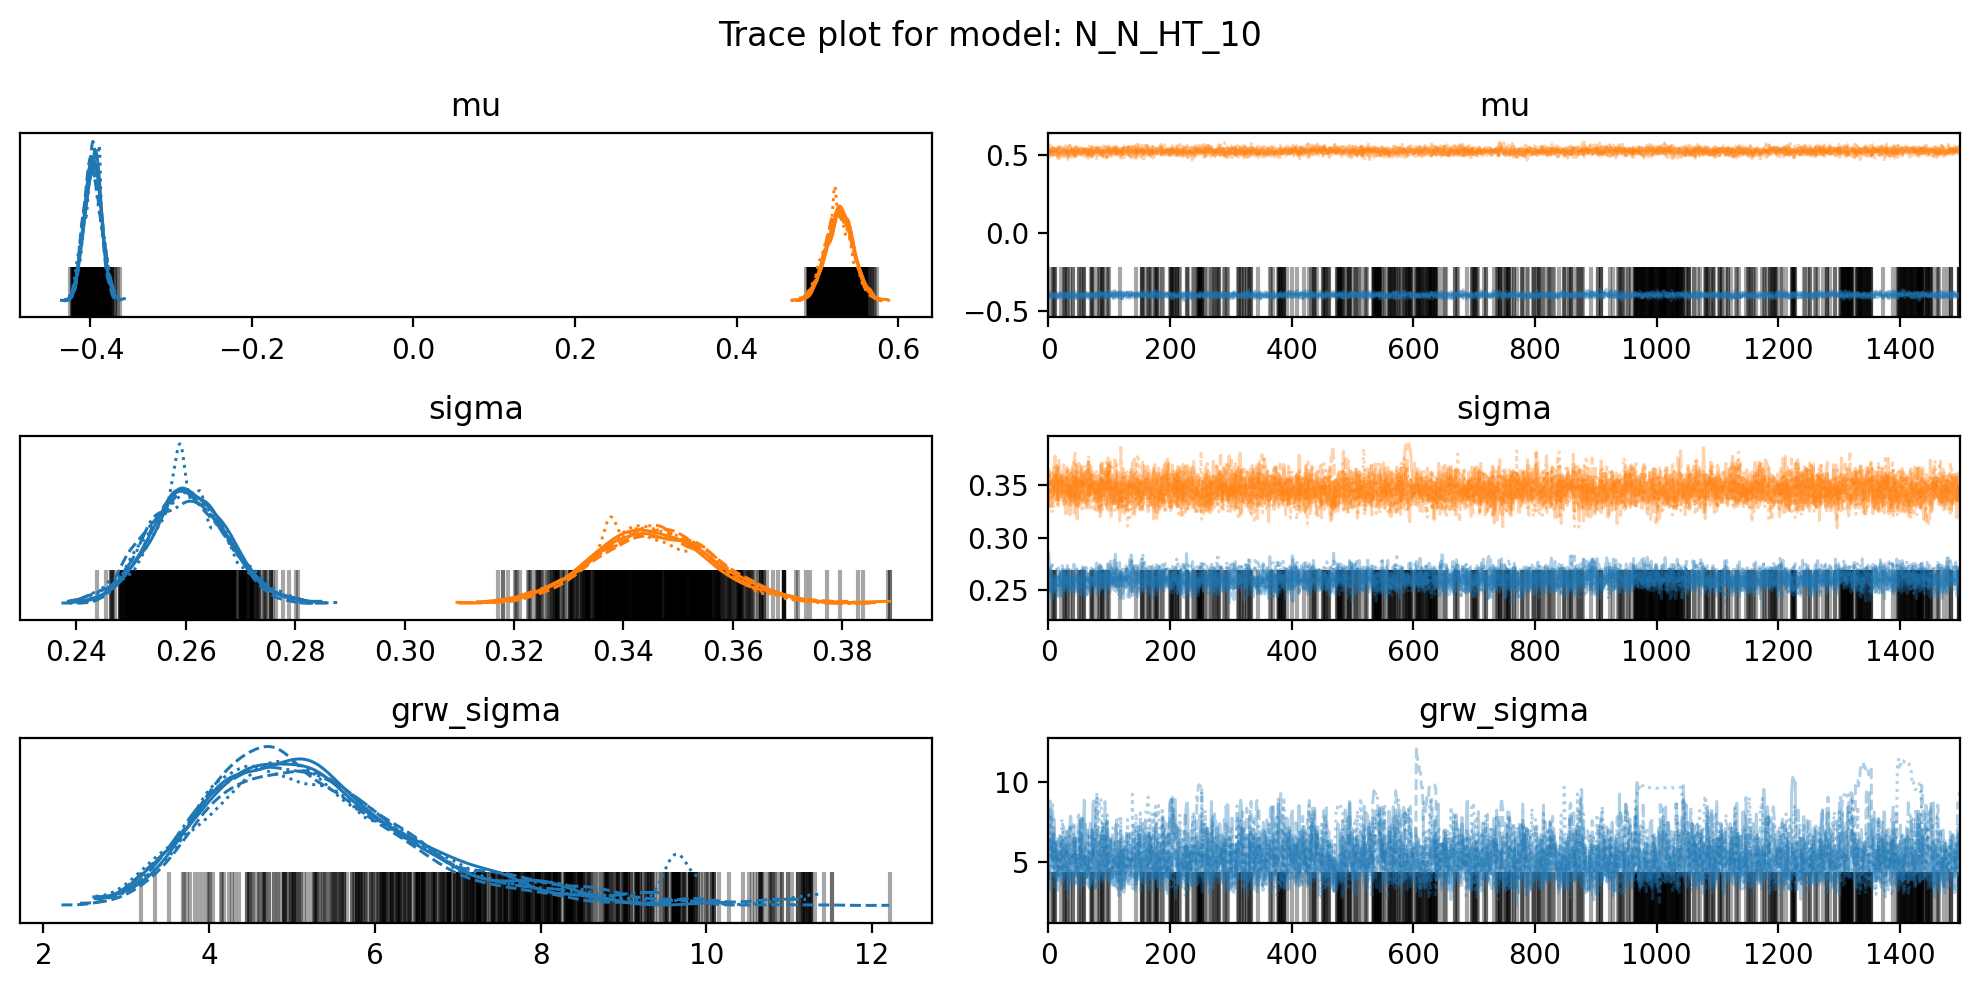

/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


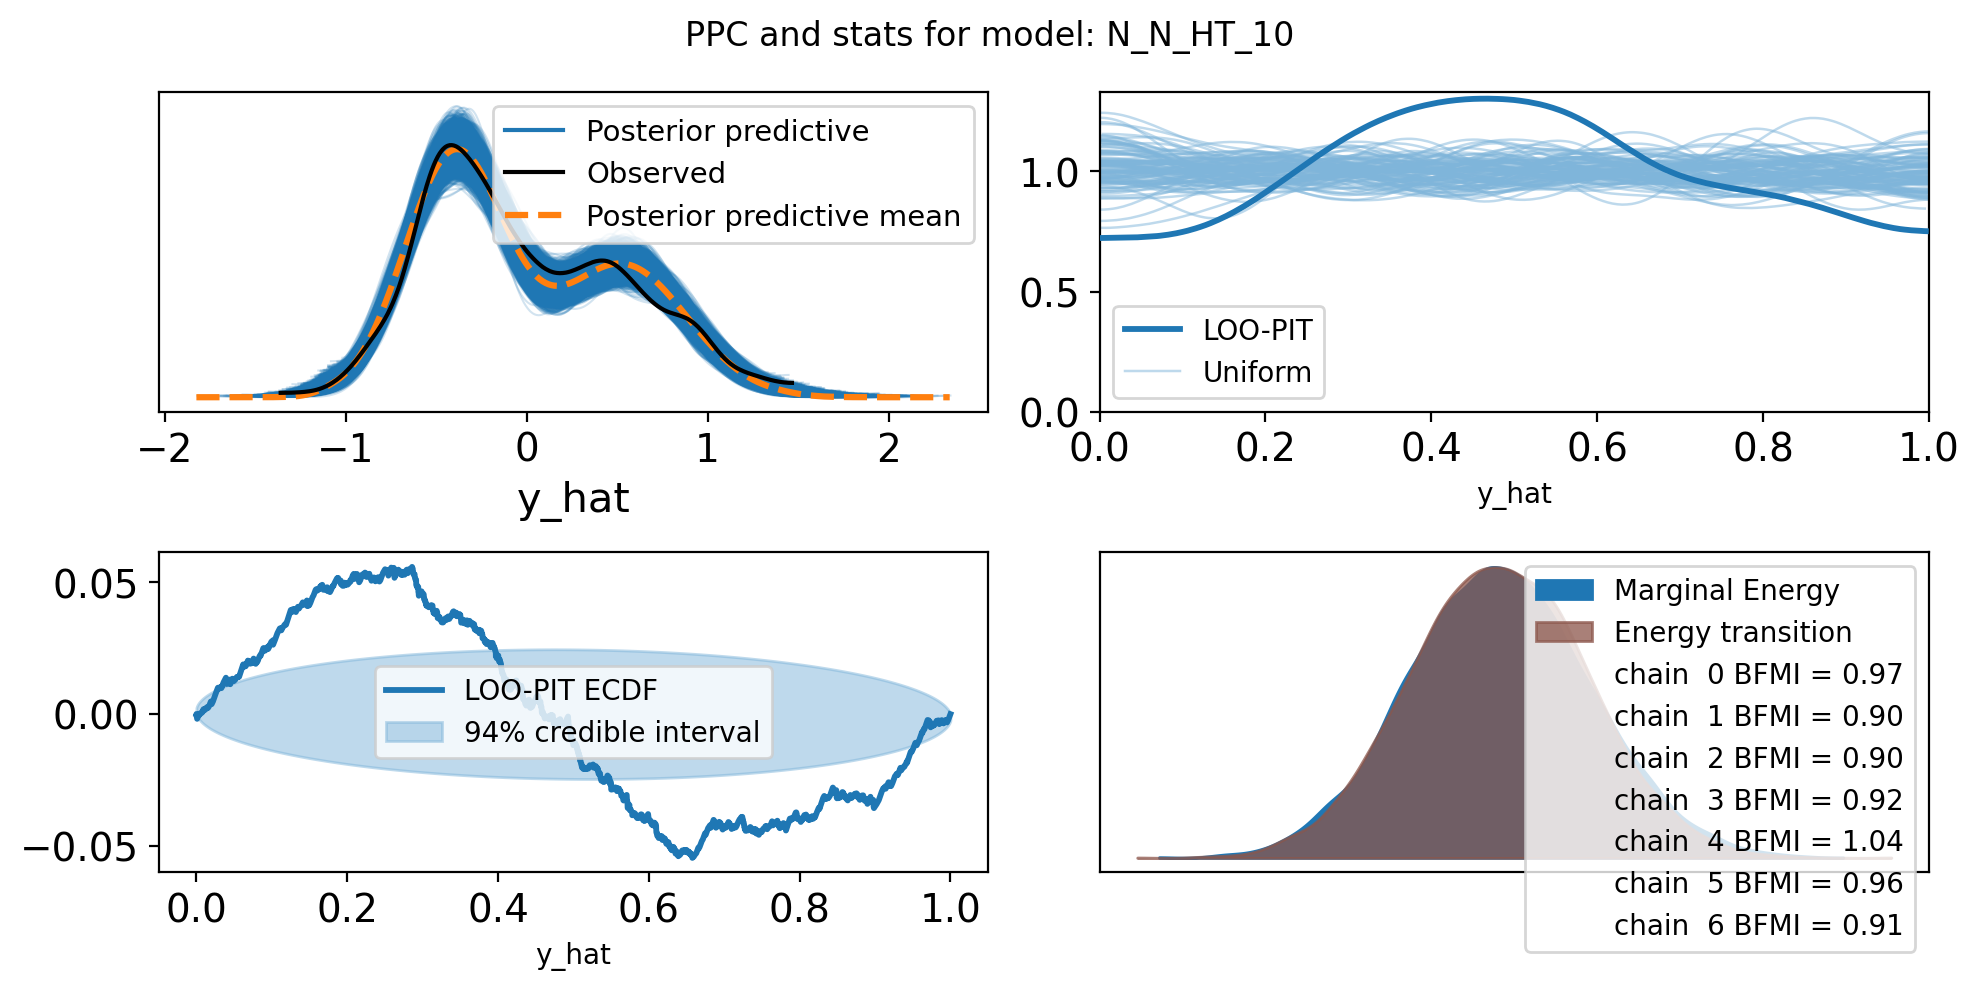

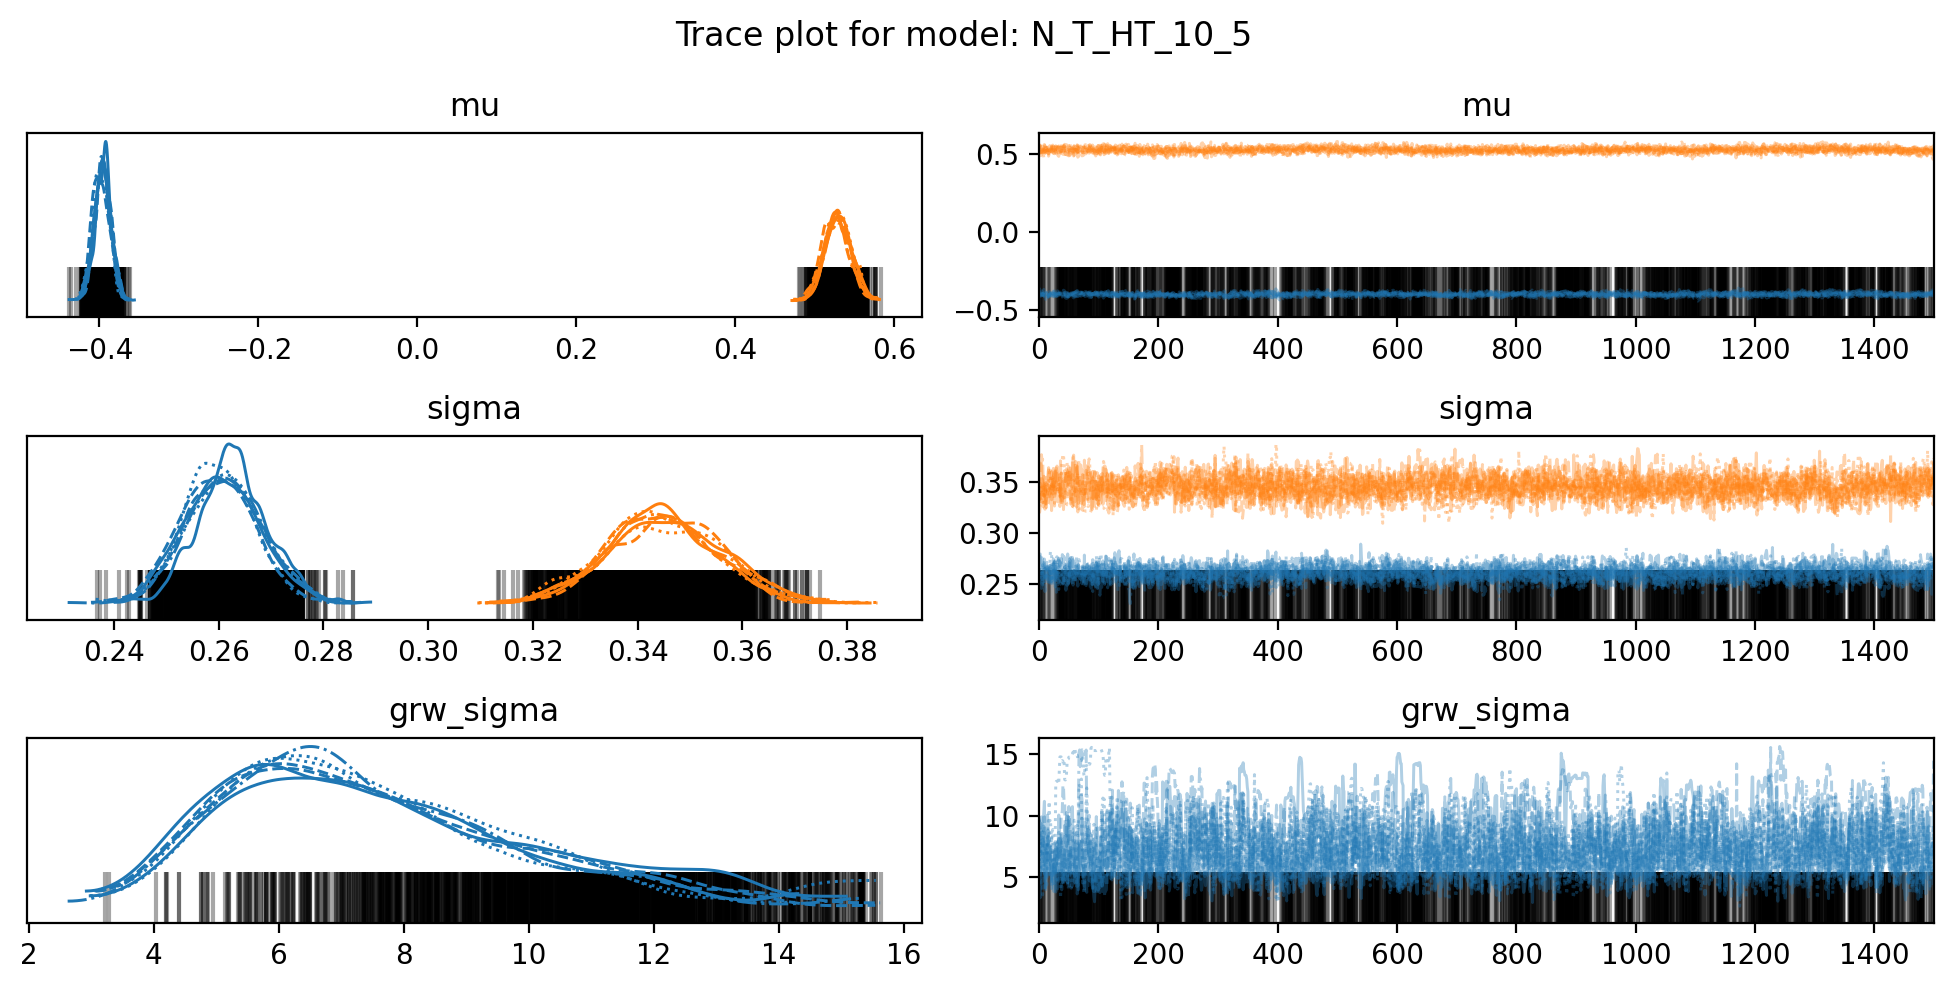

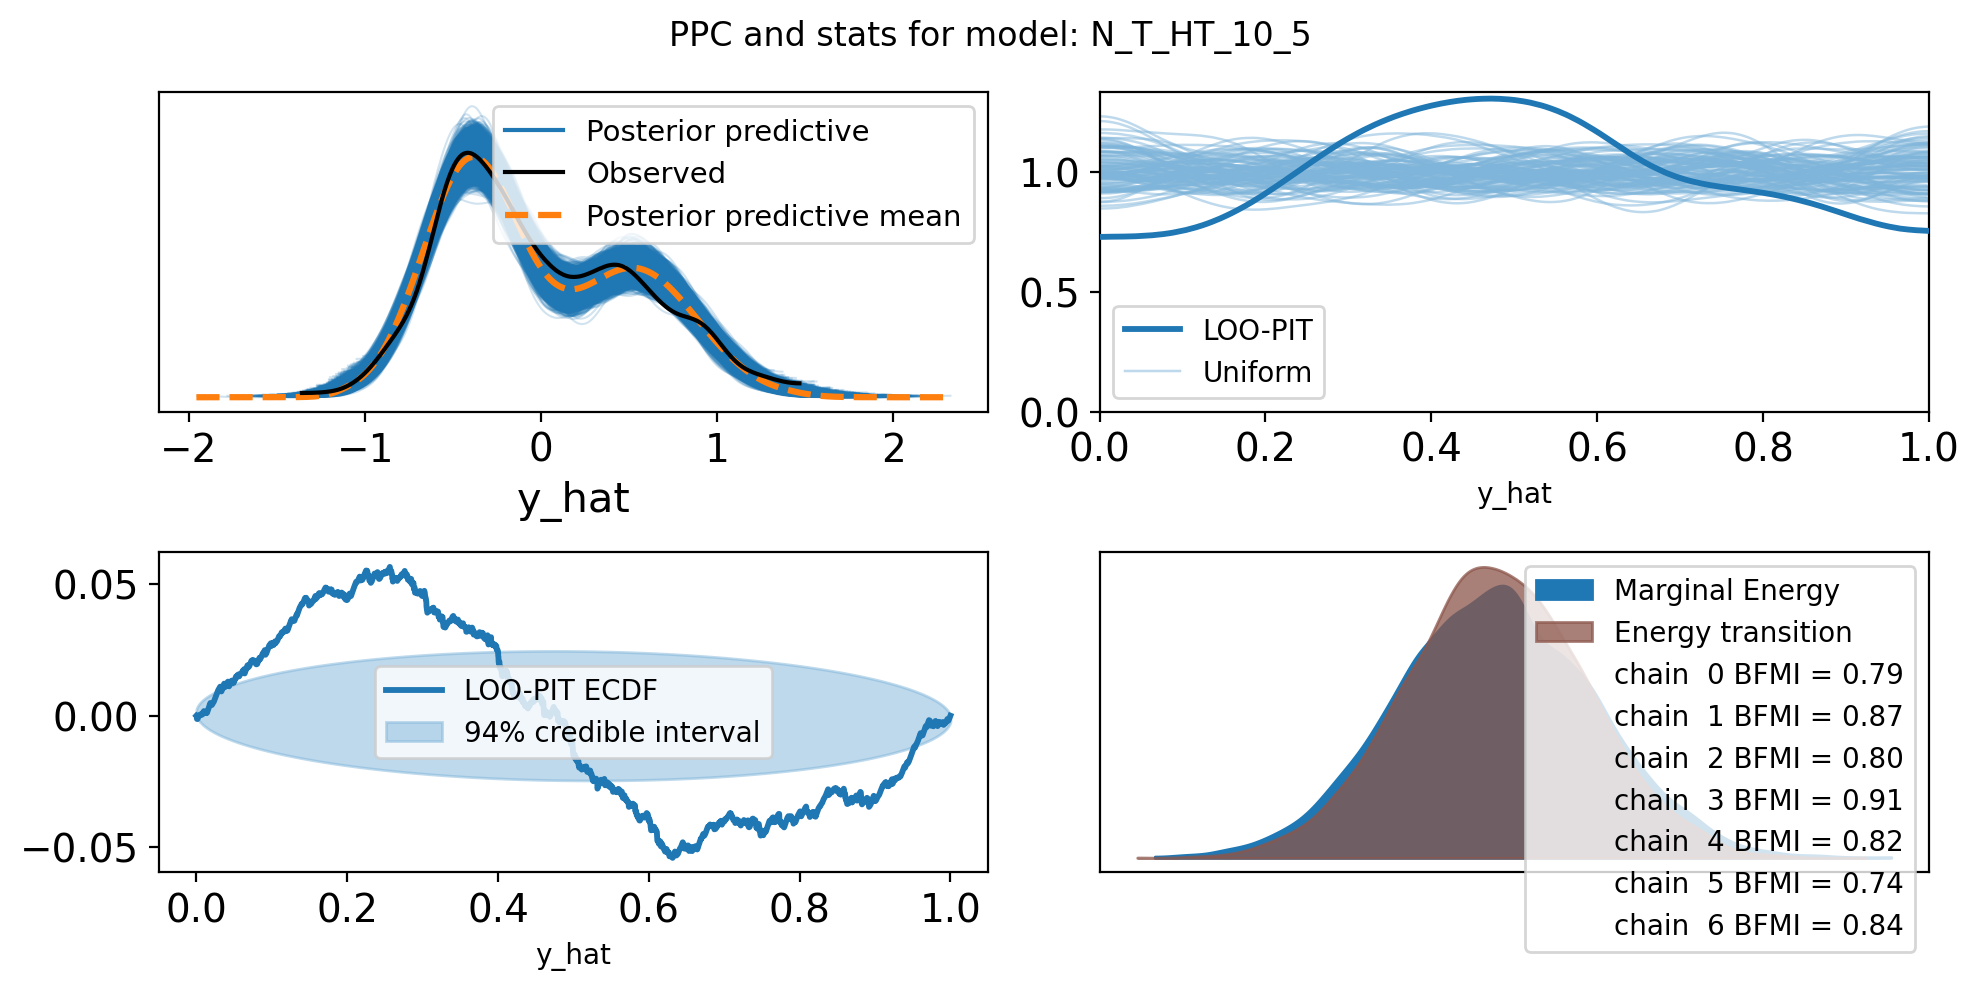

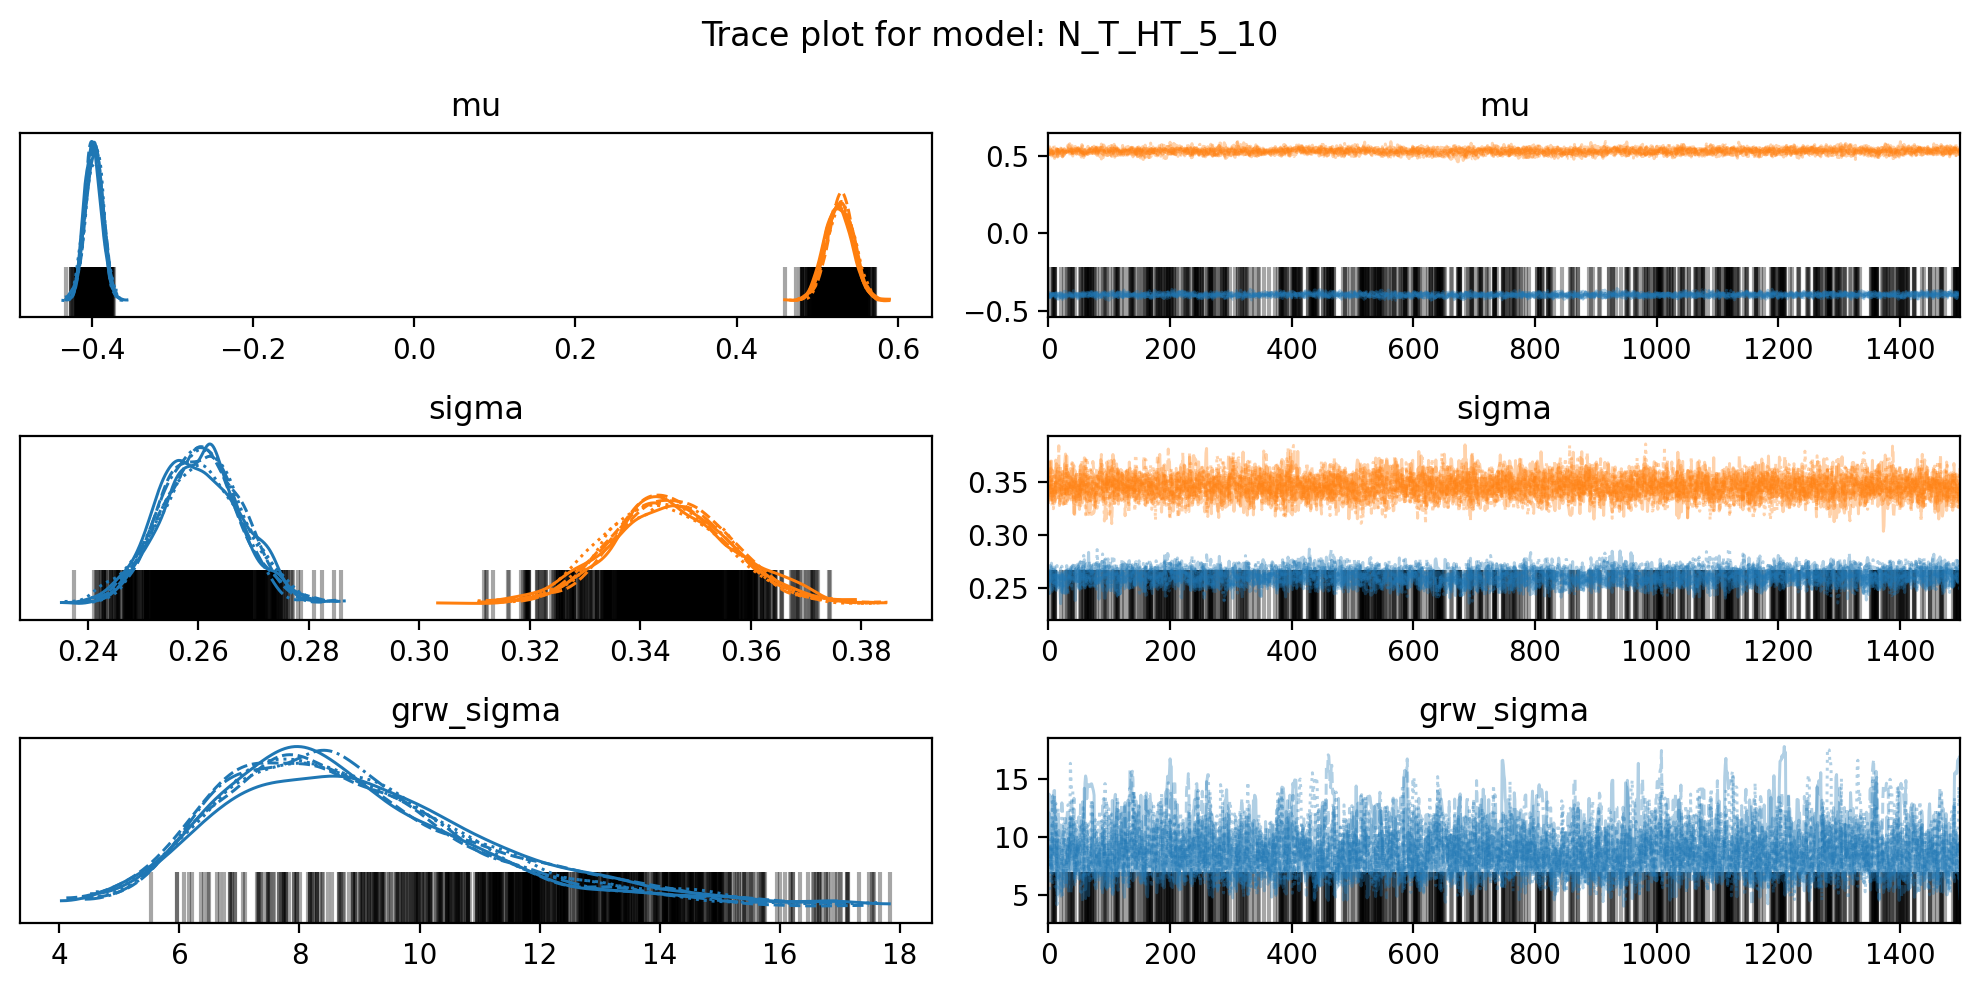

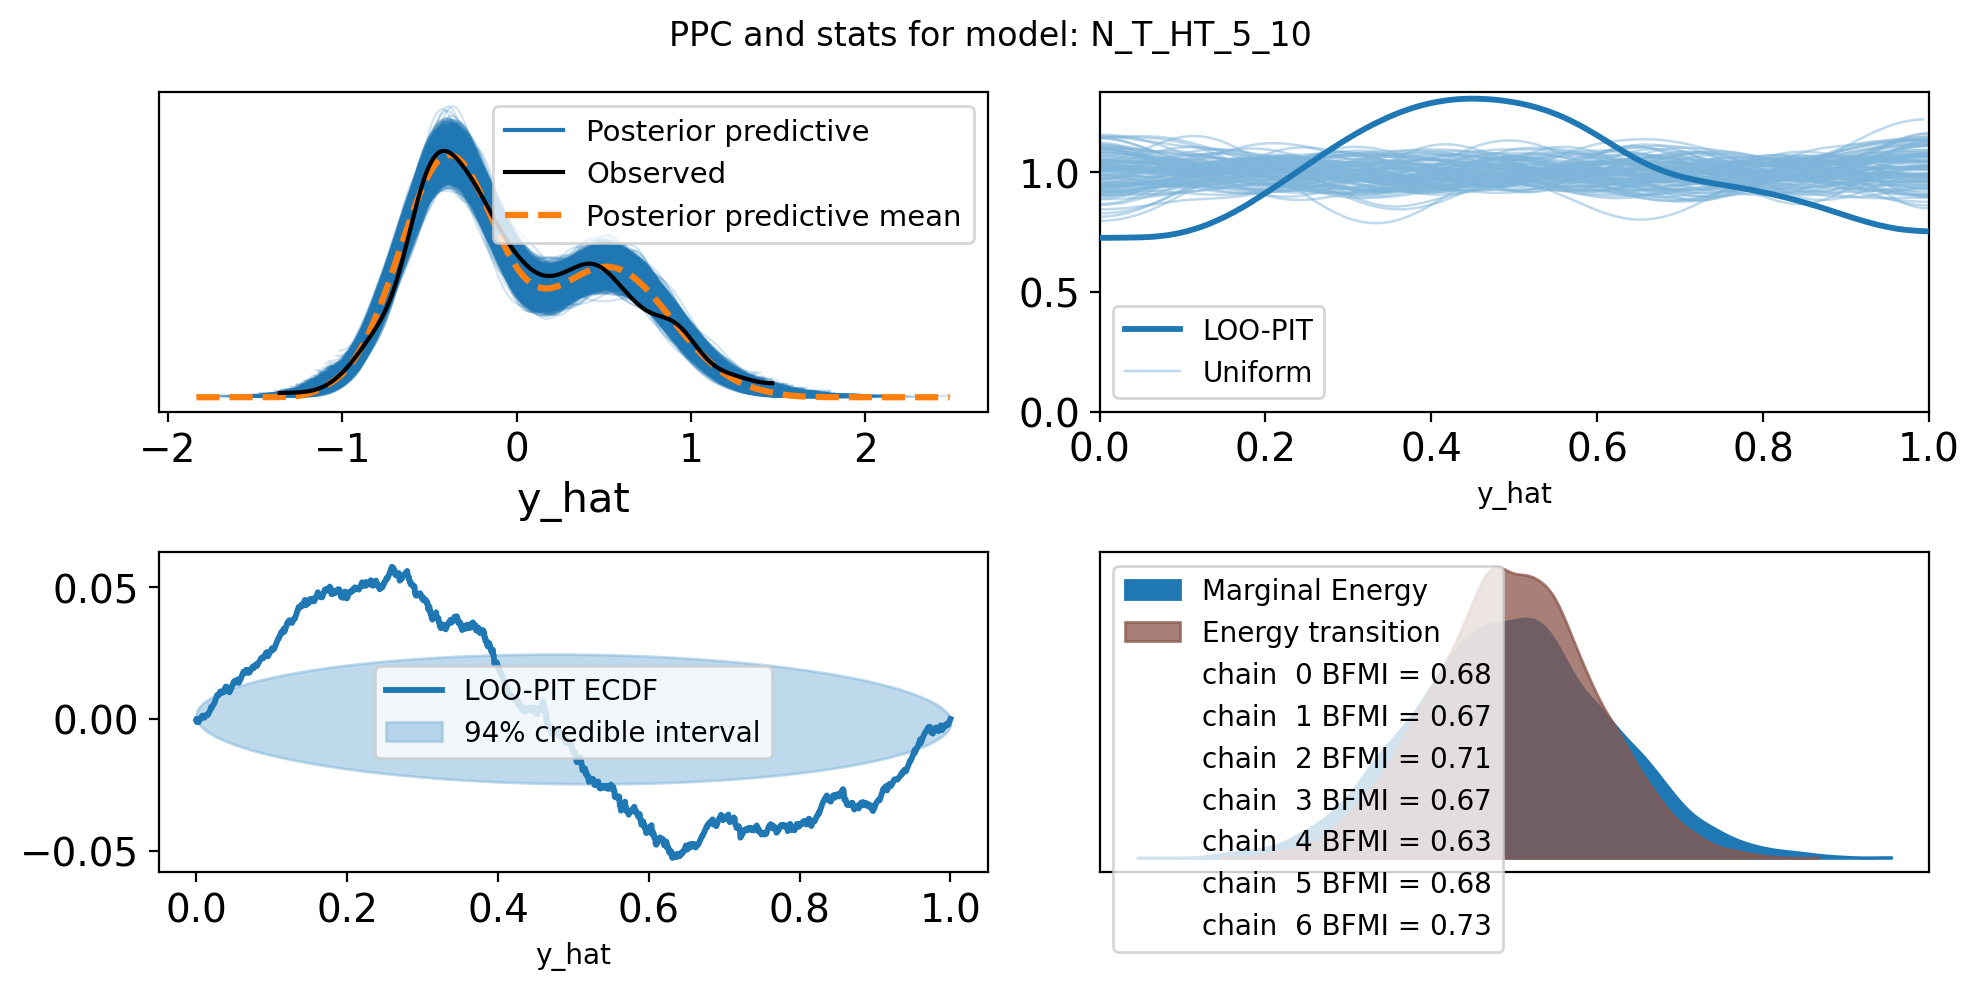

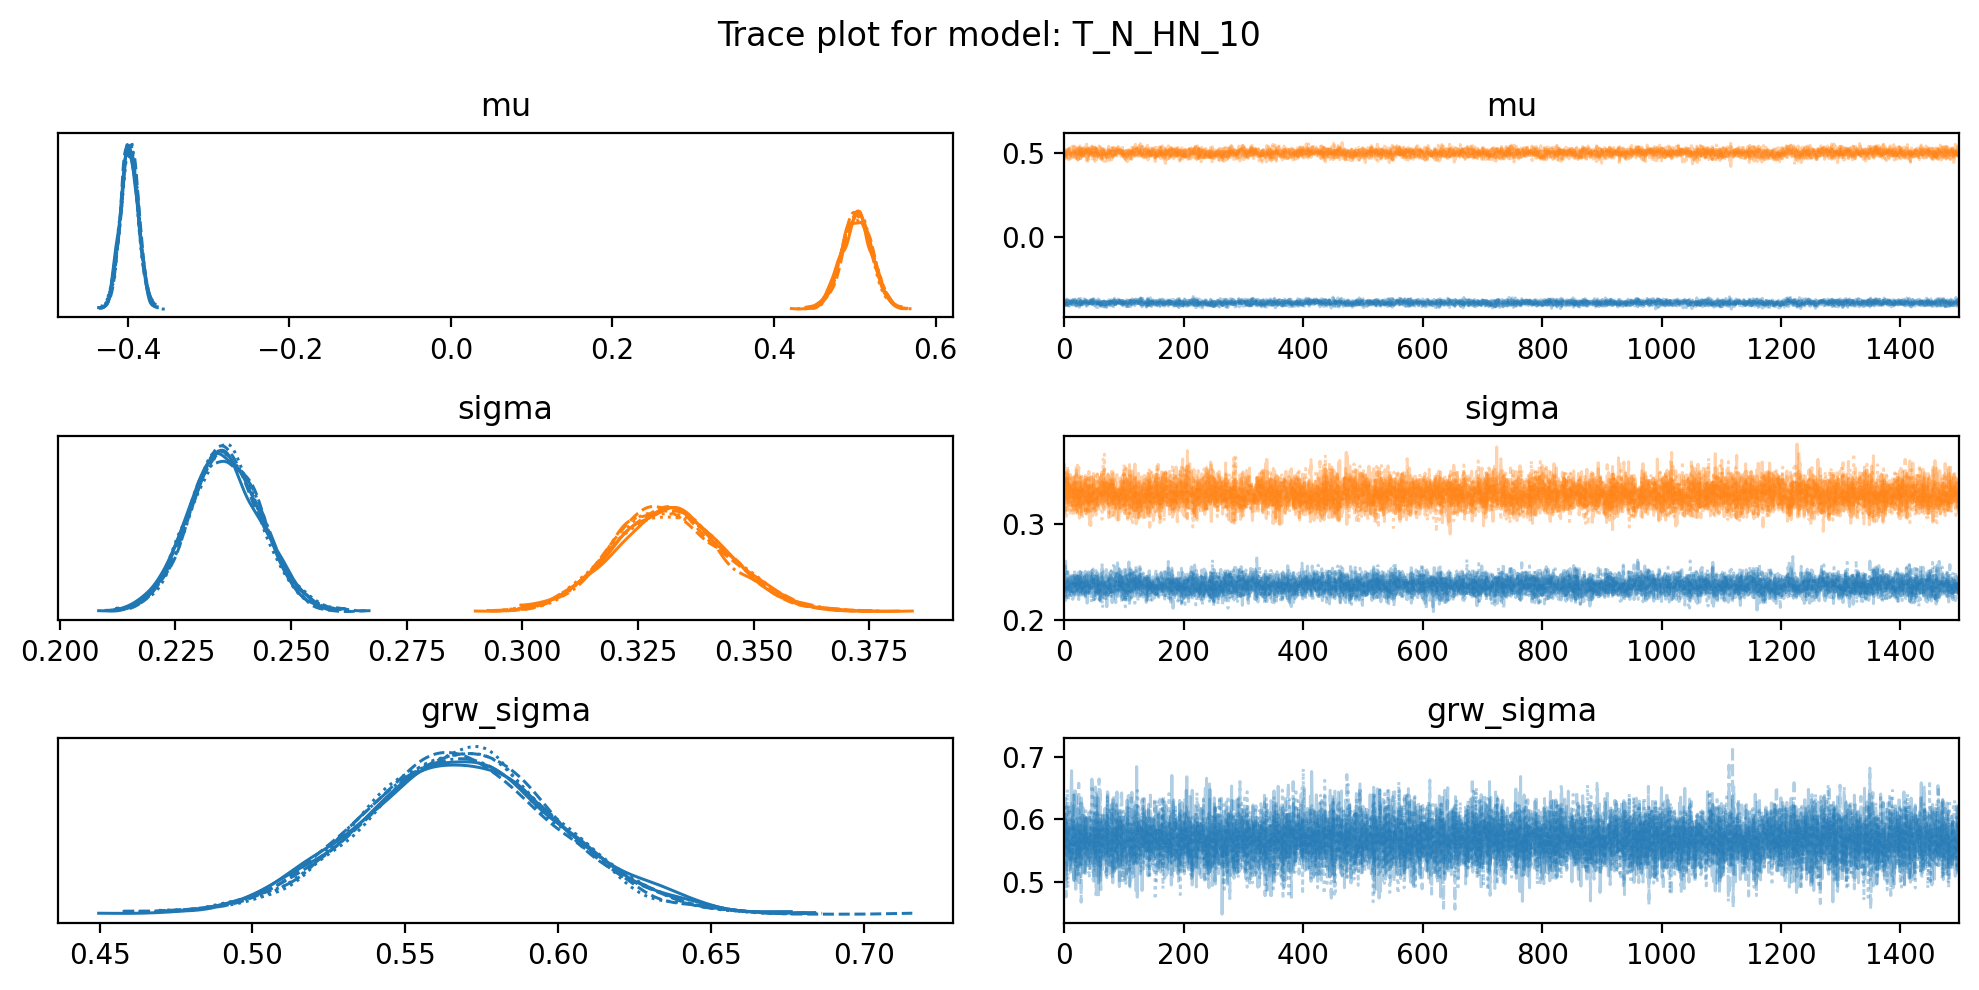

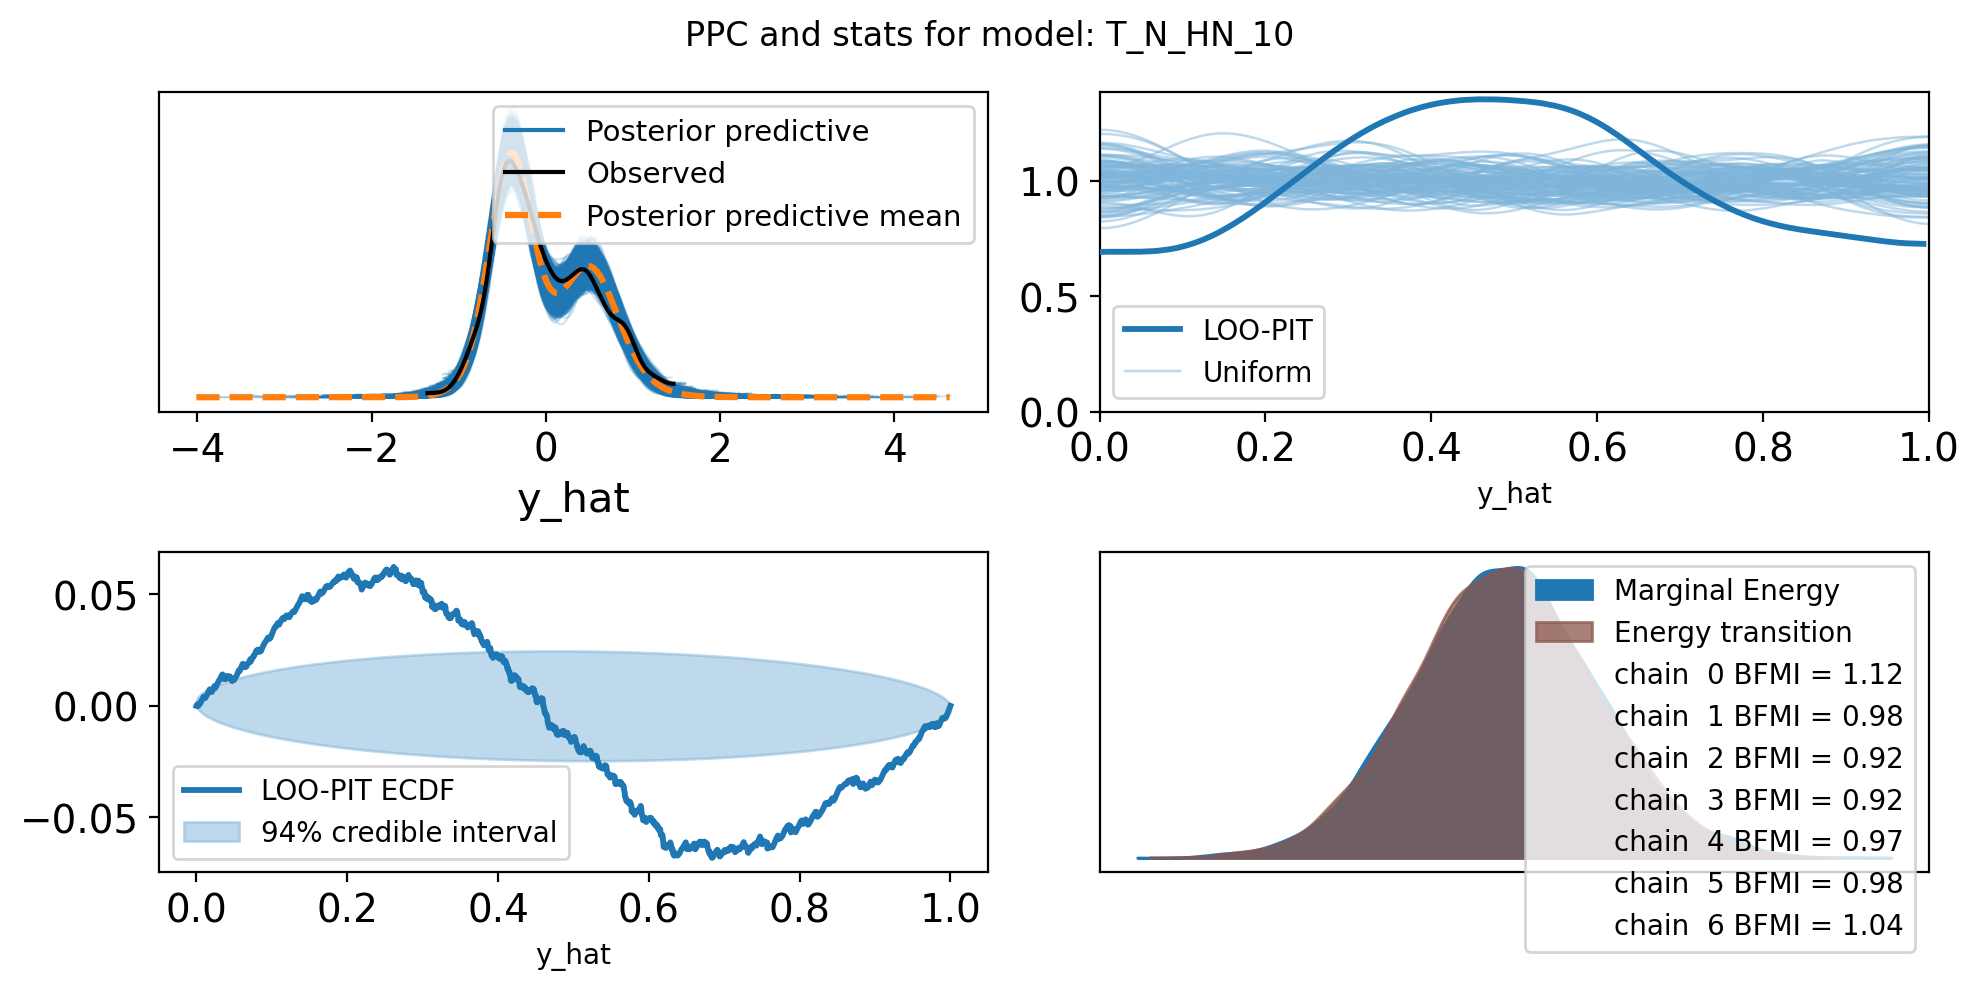

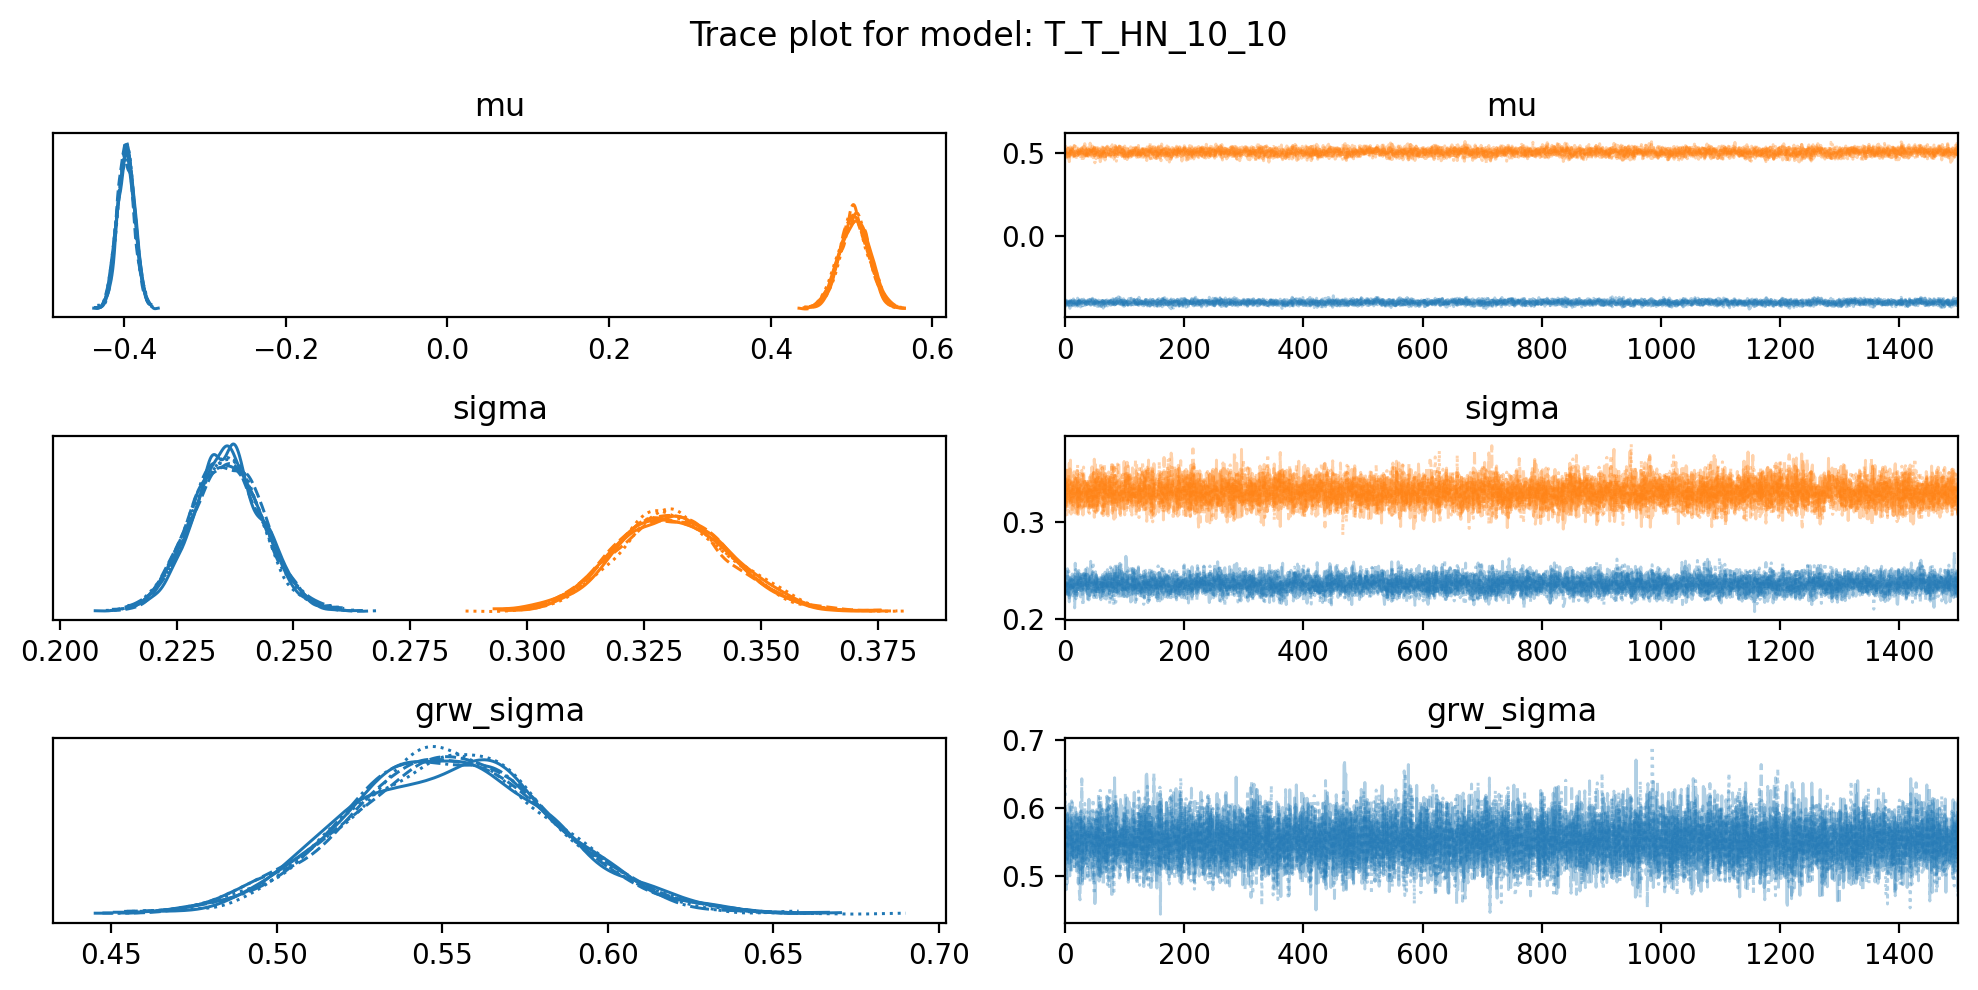

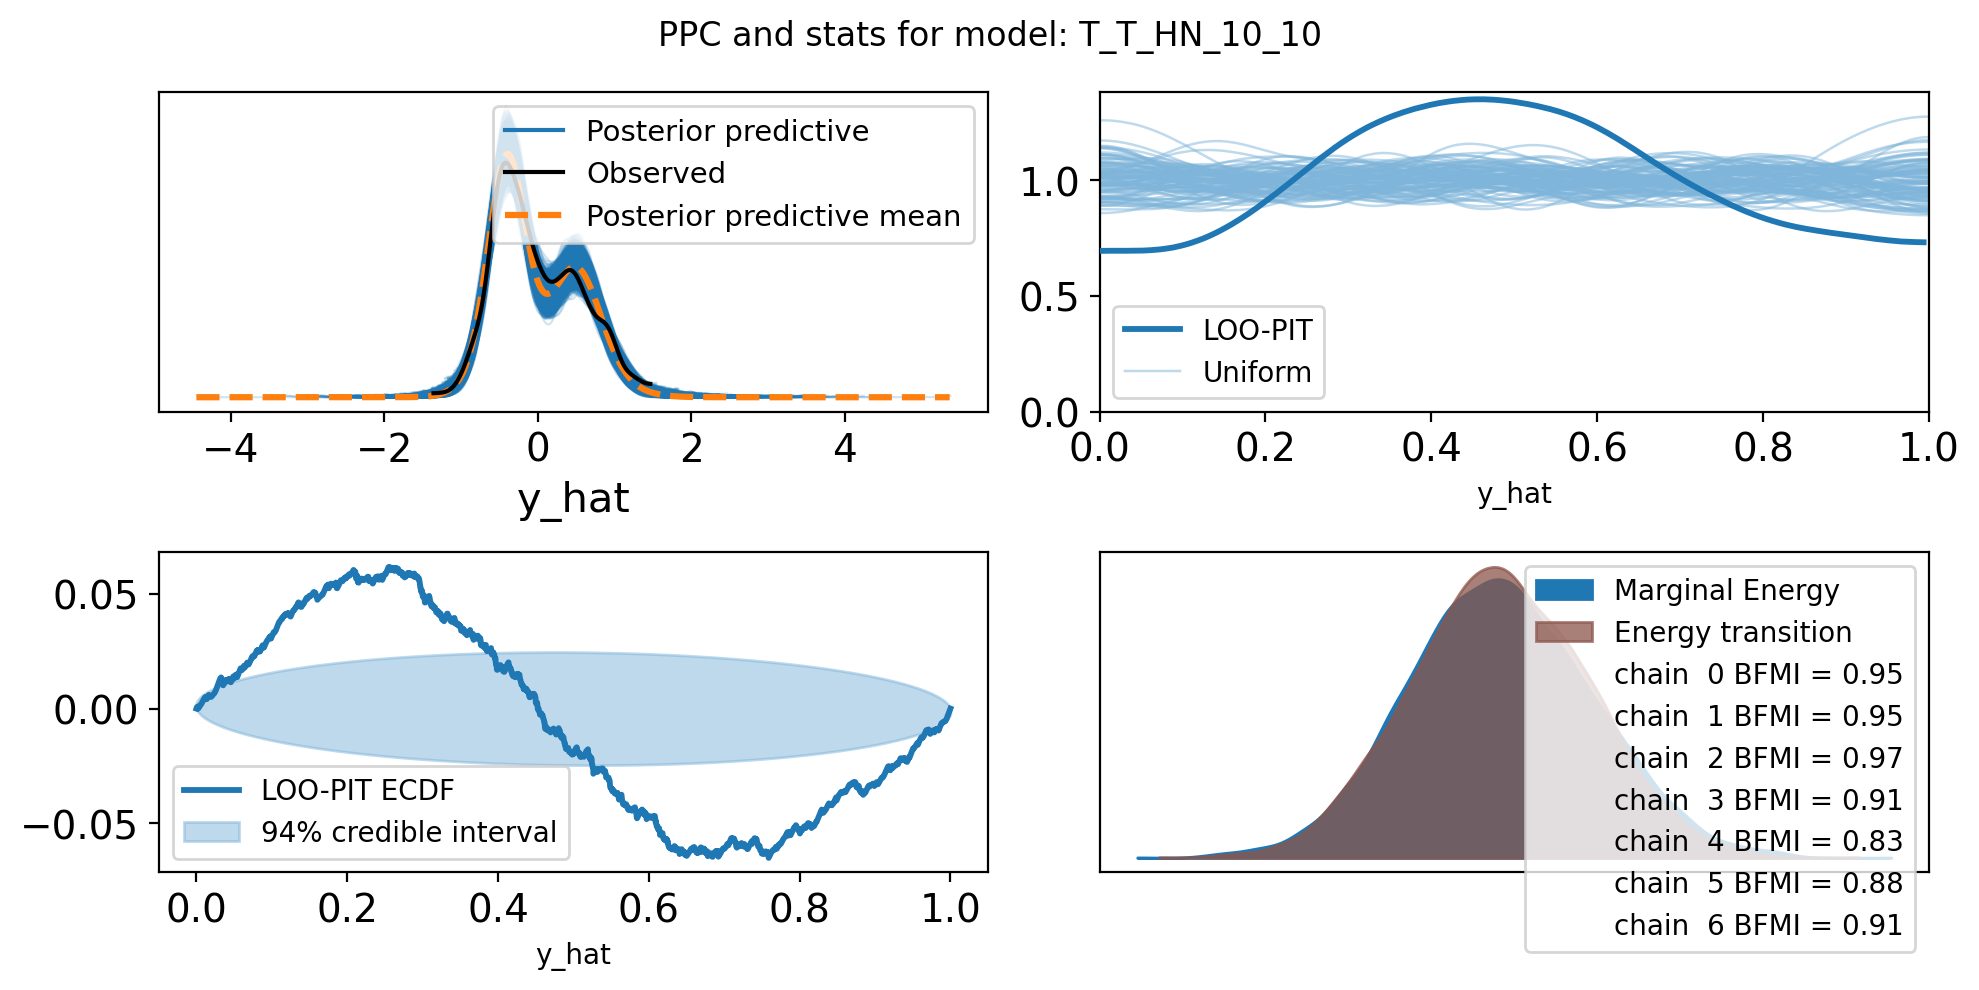

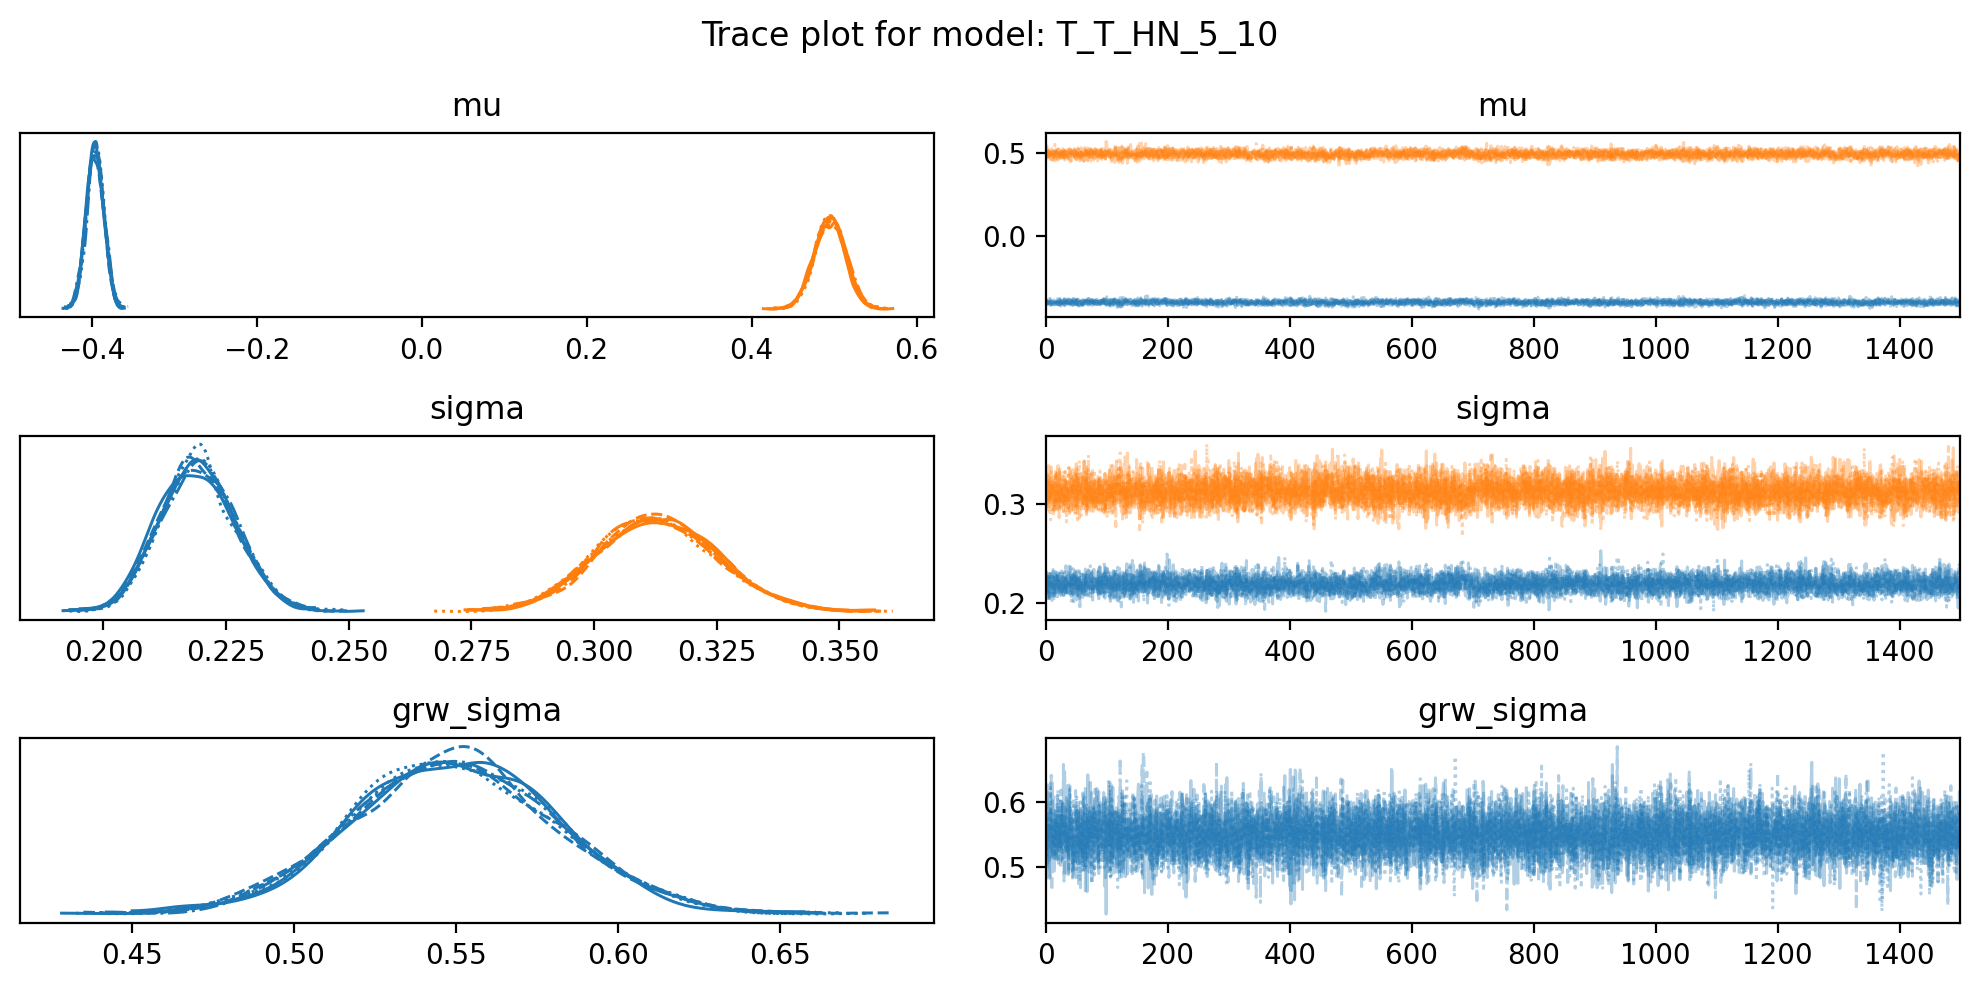

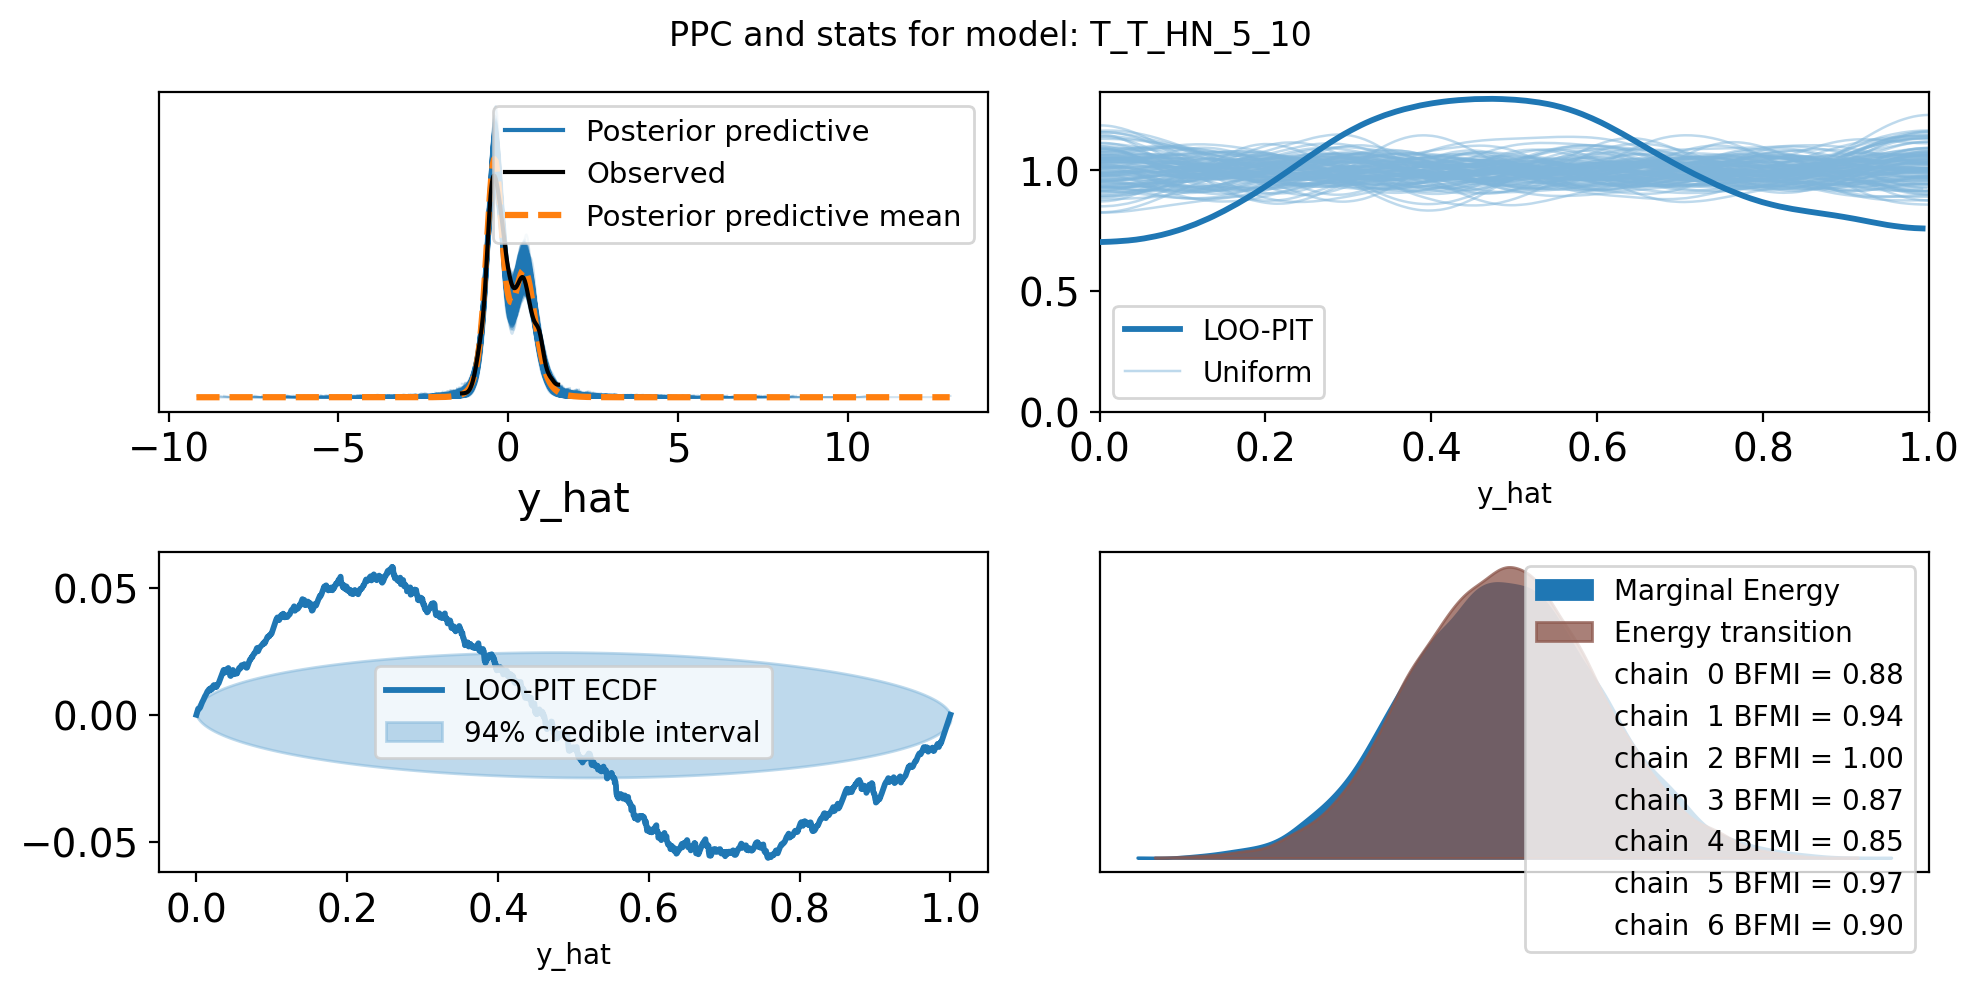

In [18]:
#| lightbox: 
#|   group: trace_stats

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

for name,d in model_traces.items():
    trace = d['trace']
    score = d['scores']['loo']

    f, axs = plt.subplots(3, 2, figsize=(10, 5))
    az.plot_trace(trace, var_names=["mu", "sigma", "grw_sigma"], compact=True, axes = axs)
    plt.suptitle(f"Trace plot for model: {name}")
    plt.tight_layout()



    f,axs = plt.subplots(2, 2, figsize=(10, 5))
    axs = axs.flatten()

    az.plot_ppc(trace, var_names=["y_hat"], ax=axs[0])
    az.plot_loo_pit(trace, y="y_hat", ax=axs[1])
    az.plot_loo_pit(trace, y="y_hat", ax=axs[2], ecdf=True)
    az.plot_energy(trace, ax = axs[3])
    plt.suptitle(f"PPC and stats for model: {name}")
    plt.tight_layout()

### Save the models and traces

In [19]:
import os.path as op
import os
import cloudpickle

# Save the traces to file (netcdf)

dir = "../results"

for name, d in model_traces.items():
    name = name+ "_z"
    # Save the model.Model as a cloudpickle.dumps
    os.makedirs(op.join(dir, "models"), exist_ok=True)
    model_path = op.join(dir, "models", f"{name}_model.pkl")
    # print(model_path)
    with open(model_path, "wb") as f:
        cloudpickle.dump(d['model'], f)

    # Save the trace as a netcdf file
    trace_path = op.join(dir, "traces", f"{name}_trace.nc")
    os.makedirs(op.dirname(trace_path), exist_ok=True)
    az.to_netcdf(d['trace'], trace_path)